# Assignment 3 - Reed Baumgardner
### Due 9/23. Do four of five.

1. 
- Open the NHANES (or Ames prices or college completion datasets, if you prefer)
- Find two categorical variables of interest (there are 198, and short descriptions are given in the `nhanes_meta_17_18.csv` file). Investigate their missing values (you don't have to focus on missing values for this analysis like we did with police use of force, but always be aware of how dirty the data are)
- Compute a contingency table for your categorical $X$ and $Y$
- Discuss any interesting patterns (or lack of one) that you observe

In [12]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


data = pd.read_csv("data/nhanes_data_17_18.csv")
meta = pd.read_csv("data/nhanes_meta_17_18.csv")

print("# of Rows:", data.shape[0])
print("# of Variables:", data.shape[1])
print("# of Metadata Variables:", meta.shape[0])

display(meta[['Variable', 'Label', 'Target']].head(200))

# of Rows: 8366
# of Variables: 198
# of Metadata Variables: 197


C:\Users\speed\AppData\Local\Temp\ipykernel_18316\3930565949.py:7: DtypeWarning: Columns (142) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv("data/nhanes_data_17_18.csv")


,Variable,Label,Target
0,HSD010,General health condition,Both males and females 12 YEARS -\n\n\t\t\t15...
1,DBQ010,Ever breastfed or fed breastmilk,Both males and females 0 YEARS -\n\n\t\t\t6 Y...
2,DBD030,Age stopped breastfeeding(days),Both males and females 0 YEARS -\n\n\t\t\t6 Y...
3,DBD041,Age first fed formula(days),Both males and females 0 YEARS -\n\n\t\t\t6 Y...
4,DBD050,Age stopped receiving formula(days),Both males and females 0 YEARS -\n\n\t\t\t6 Y...
...,...,...,...
192,SMQ852U,Unit of measure (day/week/month/year),Both males and females 18 YEARS -\n\n\t\t\t15...
193,WHD010,Current self-reported height (inches),Both males and females 16 YEARS -\n\n\t\t\t15...
194,WHD020,Current self-reported weight (pounds),Both males and females 16 YEARS -\n\n\t\t\t15...
195,WHQ070,Tried to lose weight in past year,Both males and females 16 YEARS -\n\n\t\t\t15...


In [4]:
pd.set_option("display.max_columns", None)
data.head()

,SEQN,GeneralHealthCondition,EverBreastfedOrFedBreastmilk,AgeStoppedBreastfeedingdays,AgeFirstFedFormuladays,AgeStoppedReceivingFormuladays,AgeStartedOtherFoodbeverage,AgeFirstFedMilkdays,TypeOfMilkFirstFedWholeMilk,TypeOfMilkFirstFed2Milk,TypeOfMilkFirstFed1Milk,TypeOfMilkFirstFedFatFreeMilk,TypeOfMilkFirstFedSoyMilk,TypeOfMilkFirstFedOther,HowHealthyIsTheDiet,Past30DayMilkProductConsumption,YouDrinkWholeOrRegularMilk,YouDrink2FatMilk,YouDrink1FatMilk,YouDrinkFatFreeskimMilk,YouDrinkSoyMilk,YouDrinkAnotherTypeOfMilk,RegularMilkUse5TimesPerWeek,HowOftenDrankMilkAge512,HowOftenDrankMilkAge1317,HowOftenDrankMilkAge1835,CommunitygovernmentMealsDelivered,EatMealsAtCommunityseniorCenter,AttendKindergartenThruHighSchool,SchoolServesSchoolLunches,OfTimesweekGetSchoolLunch,SchoolLunchFreeReducedOrFullPrice,SchoolServeCompleteBreakfastEachDay,OfTimesweekGetSchoolBreakfast,SchoolBreakfastFreereducedfullPrice,SummerProgramMealFreereducedPrice,OfMealsNotHomePrepared,OfMealsFromFastFoodOrPizzaPlace,OfReadytoeatFoodsInPast30Days,OfFrozenMealspizzaInPast30Days,HeardOfMyPlate,LookedUpMyPlateOnInternet,TriedMyPlatePlan,MainMealPlannerpreparer,SharedMealPlanningpreparingDuty,MainFoodShopper,SharedFoodShoppingDuty,HaveSeriousDifficultyHearing,HaveSeriousDifficultySeeing,HaveSeriousDifficultyConcentrating,HaveSeriousDifficultyWalking,HaveDifficultyDressingOrBathing,HaveDifficultyDoingErrandsAlone,HowOftenDoYouFeelWorriedOrAnxious,TakeMedicationForTheseFeelings,HowOftenDoYouFeelDepressed,TakeMedicationForDepression,CoveredByHealthInsurance,UsualSleepTimeOnWeekdaysOrWorkdays,UsualWakeTimeOnWeekdaysOrWorkdays,SleepHoursWeekdaysOrWorkdays,HowOftenDoYouSnore,EverToldDoctorHadTroubleSleeping,HowOftenFeelOverlySleepyDuringDay,HaveLittleInterestInDoingThings,FeelingDownDepressedOrHopeless,TroubleSleepingOrSleepingTooMuch,FeelingTiredOrHavingLittleEnergy,PoorAppetiteOrOvereating,FeelingBadAboutYourself,TroubleConcentratingOnThings,MovingOrSpeakingSlowlyOrTooFast,ThoughtYouWouldBeBetterOffDead,DifficultyTheseProblemsHaveCaused,SmokedTobaccoLast5Days,DaysSmokedCigarettesLast5Days,CigarettesSmokedPerDay,UsedAnyTobaccoProductLast5Days,ExperienceConfusionmemoryProblems,PhysicalMentalEmotionalLimitations,DifficultyManagingMoney,60SecHr30SecHr2,60SecPulse30SecPulse2,SystolicBloodPres1StRdgMmHg,DiastolicBloodPres1StRdgMmHg,SystolicBloodPres2NdRdgMmHg,DiastolicBloodPres2NdRdgMmHg,SystolicBloodPres3RdRdgMmHg,DiastolicBloodPres3RdRdgMmHg,EnergyKcal_DR2TOT,ProteinGm_DR2TOT,CarbohydrateGm_DR2TOT,TotalSugarsGm_DR2TOT,DietaryFiberGm_DR2TOT,TotalFatGm_DR2TOT,TotalSaturatedFattyAcidsGm_DR2TOT,TotalMonounsaturatedFattyAcidsGm_DR2TOT,TotalPolyunsaturatedFattyAcidsGm_DR2TOT,CholesterolMg_DR2TOT,AlcoholGm_DR2TOT,WeightKg,RecumbentLengthCm,StandingHeightCm,BodyMassIndexKgm2,WaistCircumferenceCm,DirectHdlcholesterolMgdl,TotalCholesterolMgdl,VigorousWorkActivity,ModerateWorkActivity,WalkOrBicycle,VigorousRecreationalActivities,ModerateRecreationalActivities,MinutesSedentaryActivity,EverBeenToldYouHaveAsthma,DoctorEverSaidYouHadArthritis,EverToldYouHadHeartAttack,AgeWhenToldYouHadHeartAttack,EverToldYouHadAStroke,AgeWhenToldYouHadAStroke,EverToldYouHadCancerOrMalignancy,1StCancerWhatKindWasIt,Age1StCancerMcq230ADiagnosed,EverUsedMarijuanaOrHashish,DaysUsedMarijuanaOrHashishmonth,EverUsedCocaineheroinmethamphetamine,EverUseAnyFormOfCocaine,OfDaysUsedCocainemonth,EverUsedHeroin,OfDaysUsedHeroinmonth,EverUsedMethamphetamine,DaysUsedMethamphetaminemonth,EverBeenInRehabilitationProgram,BloodLeadUgdl,BloodCadmiumUgl,BloodMercuryTotalUgl,BloodSeleniumUgl,BloodManganeseUgl,Gender,AgeInYearsAtScreening,AgeInMonthsAtScreening0To24Mos,RacehispanicOrigin,RacehispanicOriginWNhAsian,ServedActiveDutyInUsArmedForces,EducationLevelChildrenyouth619,EducationLevelAdults20,MaritalStatus,TotalNumberOfPeopleInTheHousehold,TotalNumberOfPeopleInTheFamily,OfChildren5YearsOrYoungerInHh,OfChildren617YearsOldInHh,OfAdults60YearsOrOlderInHh,AnnualHouseholdIncome,AnnualFamilyIncome,RatioOfFamilyIncomeToPovert

I have chosen 'Race/Hispanic origin w/ NH Asian' (RIDRETH3) and 'Doctor ever said you had arthritis' (MCQ160A).

In [7]:
col_race = "RacehispanicOriginWNhAsian"
col_arth = "DoctorEverSaidYouHadArthritis"

for var_id, col in [("RIDRETH3", col_race), ("MCQ160A", col_arth)]:
    missing_pct = data[col].isna().mean() * 100
    print(f"{col} ({var_id}) - Missing: {missing_pct:.2f}%")

def summarize_categories(var_id, col_name):
    meta_info = meta[meta["Variable"] == var_id][["Variable", "EnglishText", "Label"]]
    print(f"\n--- {col_name} ({var_id}) ---")
    print(meta_info.to_string(index=False))
    
    counts = data[col_name].value_counts(dropna=False).reset_index()
    counts.columns = [col_name, "Frequency"]
    print(counts)

summarize_categories("RIDRETH3", col_race)
summarize_categories("MCQ160A", col_arth)

RacehispanicOriginWNhAsian (RIDRETH3) - Missing: 0.00%
DoctorEverSaidYouHadArthritis (MCQ160A) - Missing: 37.25%

--- RacehispanicOriginWNhAsian (RIDRETH3) ---
Variable                                                                               EnglishText                            Label
RIDRETH3 Recode of reported race and Hispanic origin information, with Non-Hispanic Asian Category Race/Hispanic origin w/ NH Asian
            RacehispanicOriginWNhAsian  Frequency
0                   Non-Hispanic White       2792
1                   Non-Hispanic Black       1949
2                     Mexican American       1229
3                   Non-Hispanic Asian       1083
4                       Other Hispanic        738
5  Other Race - Including Multi-Racial        575

--- DoctorEverSaidYouHadArthritis (MCQ160A) ---
Variable                                                                                                    EnglishText                              Label
 MCQ160A Has a doctor 

In [15]:
selected_vars = [col_race, col_arth]

missing_counts = pd.DataFrame({
    var: data[var].isna().value_counts()
    for var in selected_vars
}).T

missing_pct = pd.DataFrame({
    var: data[var].isna().value_counts(normalize=True) * 100
    for var in selected_vars
}).T

print("\nMissingness Counts")
print(missing_counts)

print("\nMissingness Percentages")
print(missing_pct.round(2))


Missingness Counts
                                False   True 
RacehispanicOriginWNhAsian     8366.0     NaN
DoctorEverSaidYouHadArthritis  5250.0  3116.0

Missingness Percentages
                                False  True 
RacehispanicOriginWNhAsian     100.00    NaN
DoctorEverSaidYouHadArthritis   62.75  37.25


In [10]:
contingency_counts = pd.crosstab(
    data[col_race],
    data[col_arth],
    margins=True,
    dropna=False)

contingency_row_pct = pd.crosstab(
    data[col_race],
    data[col_arth],
    normalize="index",   
    dropna=False) * 100

contingency_col_pct = pd.crosstab(
    data[col_race],
    data[col_arth],
    normalize="columns",
    dropna=False) * 100

print("\nContingency Table: Row Percentages (race)")
print(contingency_row_pct.round(2))

print("\nContingency Table: Column Percentages (arthritis)")
print(contingency_col_pct.round(2))


Contingency Table: Row Percentages (race)
DoctorEverSaidYouHadArthritis          0.0    1.0    NaN
RacehispanicOriginWNhAsian                              
Mexican American                     44.26  12.37  43.37
Non-Hispanic Asian                   58.73  11.17  30.10
Non-Hispanic Black                   43.15  20.27  36.58
Non-Hispanic White                   39.29  25.32  35.39
Other Hispanic                       48.64  18.02  33.33
Other Race - Including Multi-Racial  29.22  16.87  53.91

Contingency Table: Column Percentages (arthritis)
DoctorEverSaidYouHadArthritis          0.0    1.0    NaN
RacehispanicOriginWNhAsian                              
Mexican American                     14.92   9.47  17.11
Non-Hispanic Asian                   17.45   7.54  10.46
Non-Hispanic Black                   23.07  24.61  22.88
Non-Hispanic White                   30.10  44.05  31.71
Other Hispanic                        9.85   8.29   7.89
Other Race - Including Multi-Racial   4.61   6.04  

From the contingency tables, I noticed that among each racial group, non-hispanic whites have the highest arthritis prevalence at around 25%, closely followed by non-hispanic blacks at 20%. I do not see uniformity among groups in this regard as non-hispanic asians and mexican americans are both reporting lower prevalences. Now, within the group of people who have arthritis, whites make up the largest share around 44%, with second being blacks at 25%. I notice a fair bit of missing data, which as we saw before, is completely from the arthritis column. The missing values are decently spread around but there are definitely some races with bigger percentages like other-race on the row pecentages table and whites on the column percentages table.

2. 
- Open the NHANES dataset
- Find a categorical and numeric variable of interest (there are 198, and short descriptions are given in the `nhanes_meta_17_18.csv` file). Investigate their missing values (you don't have to focus on missing values for this analysis, but always be aware of them)
- Make descriptive tables and grouped kernel density plots to represent the variation in your numeric $Y$ conditional on your categorical $X$
- Discuss any interesting patterns (or lack of one) that you observe

I will continue using 'doctor ever said you had arthritis' (MCQ160A) and will use Weight KG (BMXWT) as the numeric variable. 

DoctorEverSaidYouHadArthritis - Missing: 37.25%
WeightKg - Missing: 1.48%

Descriptive Statistics (Weight by Arthritis Report):
                                count       mean        std   min   25%   50%  \
DoctorEverSaidYouHadArthritis                                                   
0.0                            3600.0  81.367611  22.227085  32.6  66.1  77.7   
1.0                            1573.0  86.150223  23.990346  39.3  69.3  82.6   

                                75%    max  
DoctorEverSaidYouHadArthritis               
0.0                            92.7  242.6  
1.0                            98.8  219.6  


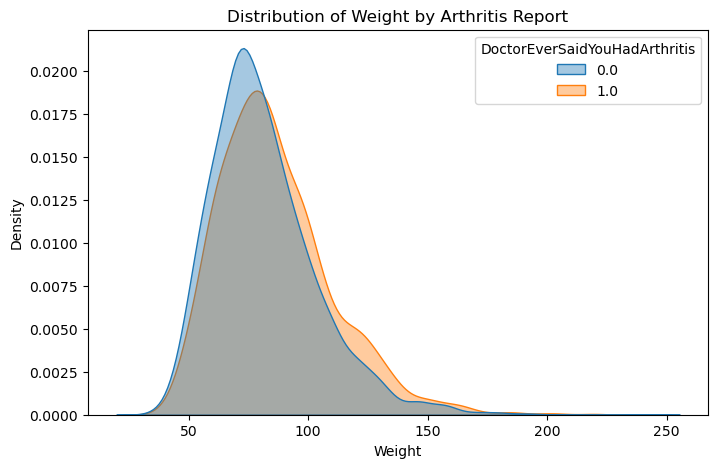

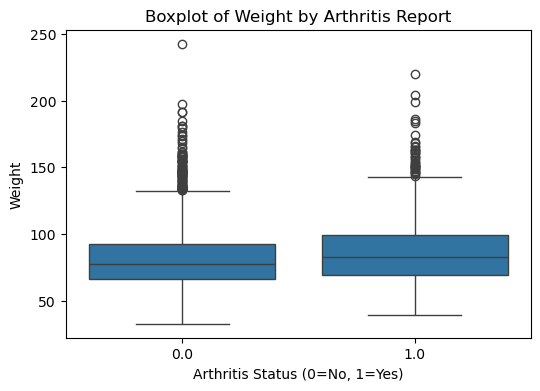

In [ ]:
col_arth = "DoctorEverSaidYouHadArthritis"   
col_wt = "WeightKg"                        

for col in [col_arth, col_wt]:
    missing_pct = data[col].isna().mean() * 100
    print(f"{col} - Missing: {missing_pct:.2f}%")

desc_stats = data.groupby(col_arth)[col_wt].describe()
print("\nDescriptive Statistics (Weight by Arthritis Report):")
print(desc_stats)

plt.figure(figsize=(8,5))
sns.kdeplot(
    data=data,
    x=col_wt,
    hue=col_arth,
    common_norm=False,
    fill=True,
    alpha=0.4)

plt.title("Distribution of Weight by Arthritis Report")
plt.xlabel("Weight")
plt.ylabel("Density")
plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(
    data=data,
    x=col_arth,
    y=col_wt)

plt.title("Boxplot of Weight by Arthritis Report")
plt.xlabel("Arthritis Status (0=No, 1=Yes)")
plt.ylabel("Weight")
plt.show()

I am seeing a noticeable trend from these plots and statistics that there is a difference in weight depending on the arthritis status of the individual. It isn't the biggest difference, though, as the mean weight of people with arthritis is 86kg, as opposed to 81kg of the non-arthritis group. The KDE shows about the same concept as the arthritis' group's plot is pushed slightly right of the non-arthritis group's. The boxplot shows about the same thing while also showing us the numerous outliers present within this analysis. Missing value percentages are low for weight (1%), but remains at a low-ish but not great 37%. Nonetheless, the low amount of missing values don't do much to persuade me off the takeaway that a higher weight is showing us a more likely probability of having arthritis.


3. 
We showed that the mean and median could be discovered by minimizing various kinds of loss functions; this is what machine learning is. To make a prediction $\hat{y}(z)$ of $Y$ when $X=z$, minimize the mean squared error:
$$
MSE(\hat{y}(z)) = \dfrac{1}{N} \sum_{i=1}^N \left\lbrace y_i - \hat{y}(z) \right\rbrace^2 \frac{1}{h}k\left(\frac{z-x_i}{h}\right)
$$
Show that the solution to this problem is the LCLS/Naradaya-Watson estimator.

$$
MSE(\hat{y}(z)) = \frac{1}{N}\sum_{i=1}^N (y_i - \hat{y}(z))^2 \, w_i(z),
\quad 
w_i(z) = \frac{1}{h} k\!\left(\frac{z - x_i}{h}\right).
$$

---

**Step 1: Differentiate wrt $\hat{y}(z)$**

$$
\frac{\partial}{\partial \hat{y}(z)} MSE(\hat{y}(z)) 
= \frac{1}{N}\sum_{i=1}^N 2(\hat{y}(z) - y_i) w_i(z)
= \frac{2}{N}\Bigg[\hat{y}(z)\sum_{i=1}^N w_i(z) - \sum_{i=1}^N w_i(z) y_i\Bigg].
$$

---

**Step 2: Set equal to zero and solve**

$$
\hat{y}(z)\sum_{i=1}^N w_i(z) = \sum_{i=1}^N w_i(z) y_i,
$$

$$
\hat{y}(z) = \frac{\sum_{i=1}^N w_i(z) y_i}{\sum_{i=1}^N w_i(z)}.
$$

---

**Step 3: Plug back in kernel weights**

Since

$$
w_i(z) = \frac{1}{h} k\!\left(\frac{z - x_i}{h}\right),
$$

we get:

$$
\hat{y}(z) = \frac{\sum_{i=1}^N k\!\left(\frac{z - x_i}{h}\right) y_i}
{\sum_{i=1}^N k\!\left(\frac{z - x_i}{h}\right)}.
$$

---

This is the LCLS/Naradaya-Watson estimator.

4. 
- Write a class or set of functions that implement the LCLS/Naradaya-Watson estimator, using the Silverman plug-in estimate for the conditioning variable $X$ as the bandwidth.
- From one of the course data sets, find two numeric variables of interest, analyze their relationship with the the LCLS/Naradaya-Watson estimator, and discuss your results.

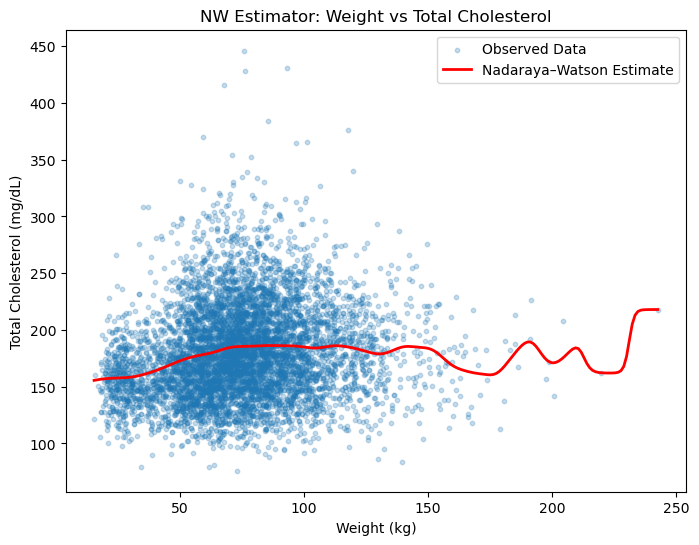

Descriptive stats:
          WeightKg  TotalCholesterolMgdl
count  6650.000000           6650.000000
mean     75.087820            179.954286
std      26.557816             40.634389
min      15.500000             76.000000
25%      58.400000            150.000000
50%      73.800000            176.000000
75%      90.175000            204.000000
max     242.600000            446.000000


In [18]:
from scipy.stats import norm

col_x = "WeightKg"     
col_y = "TotalCholesterolMgdl"  

subset = data[[col_x, col_y]].dropna()
X = subset[col_x].values
Y = subset[col_y].values


n = len(X)
h = 1.06 * np.std(X) * n ** (-1/5)

def nw_estimator(x0, X, Y, h):
    weights = norm.pdf((x0 - X) / h)
    return np.sum(weights * Y) / np.sum(weights)

x_grid = np.linspace(X.min(), X.max(), 200)
y_hat = np.array([nw_estimator(x0, X, Y, h) for x0 in x_grid])

plt.figure(figsize=(8,6))
plt.scatter(X, Y, s=10, alpha=0.25, label="Observed Data")
plt.plot(x_grid, y_hat, color="red", lw=2, label="Nadaraya–Watson Estimate")
plt.xlabel("Weight (kg)")
plt.ylabel("Total Cholesterol (mg/dL)")
plt.title("NW Estimator: Weight vs Total Cholesterol")
plt.legend()
plt.show()

print("Descriptive stats:")
print(subset.describe())

The NW estimator line on this graph shows a modest increase in cholesterol levels as weight increases before becoming erratic at very high weights, likely due to less observations (and maybe overfitting) in those ranges. I would say that the estimator shows that there may be a weak relationship between weight and cholresterol, but I would not say, based on this, that weight alone is a good predictor for total cholesterol.

5. 
- In any of the available data sets, investigate the relationships between pairs of variables $(X,Y)$ with a scatterplot and CEF (for example, price on area)
- Is this relationship plausibly causal, or are there missing variables that might explain at least part of the relationship between your variables? These can be "conceptual" rather than "practical"; for example, 'talent' or 'grit' probably explain education outcomes, but are almost impossible to measure. We are asking whether there are hypothetical **threats to causal identification** of the effect of $X$ on $Y$.
- Explain how, regardless of the threat to causal identification, you can still use your model to predict $Y$ given $X$, as long as you don't intervene in the system to control the outcome